<a href="https://colab.research.google.com/github/Abhii-00/ai_ml_lab/blob/main/simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print("Path to dataset files:", path)

100%|██████████| 457/457 [00:00<00:00, 734kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abhishek14398/salary-dataset-simple-linear-regression/versions/1


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
print(os.listdir(path))

['Salary_dataset.csv']


In [ ]:
file_path = os.path.join(path, "Salary_dataset.csv")
df = pd.read_csv(file_path)

df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
print(df.info())
print("\n")

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


       Unnamed: 0  YearsExperience         Salary
count   30.000000        30.000000      30.000000
mean    14.500000         5.413333   76004.000000
std      8.803408         2.837888   27414.429785
min      0.000000         1.200000   37732.000000
25%      7.250000         3.300000   56721.750000
50%     14.500000         4.800000   65238.000000
75%     21.750000         7.800000  100545.750000
max     29.000000        10.600000  122392.000000


In [ ]:
print(df.isnull().sum())

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [ ]:
X = df[['YearsExperience']]
y = df['Salary']

print(X.head())
print(y.head())

   YearsExperience
0              1.2
1              1.4
2              1.6
3              2.1
4              2.3
0    39344.0
1    46206.0
2    37732.0
3    43526.0
4    39892.0
Name: Salary, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 24
Testing samples : 6


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 24380.201479473704
Slope: 9423.815323030976


In [ ]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

prediction_df.head()

,Actual Salary,Predicted Salary
0,112636.0,115791.210113
1,67939.0,71499.278095
2,113813.0,102597.868661
3,83089.0,75268.804224
4,64446.0,55478.792045


In [ ]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score :", r2)
print("RMSE     :", rmse)

R² Score : 0.9024461774180497
RMSE     : 7059.04362190151


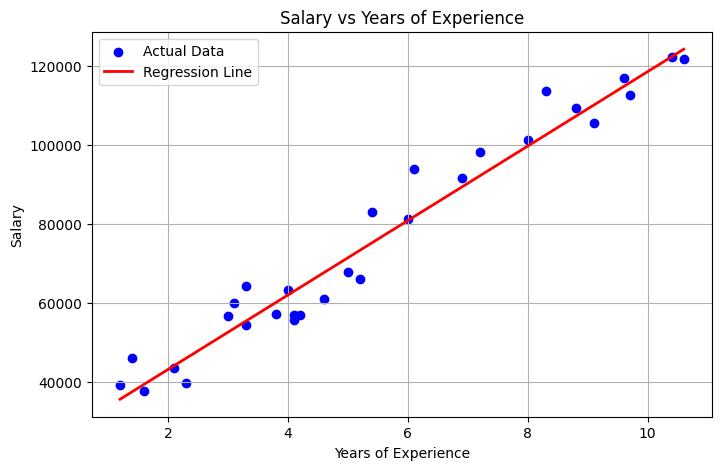

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    color="blue",
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Predict salary for 5 years of experience
experience = pd.DataFrame({
    "YearsExperience": [5]
})

predicted_salary = model.predict(experience)

print(f"Predicted Salary for 5 years of experience: {predicted_salary[0]:.2f}")

Predicted Salary for 5 years of experience: 71499.28
